In [83]:
import pandas as pd
from sklearn.model_selection import train_test_split

path = "../../data/Metadata_features/metadata_features.csv"

df = pd.read_csv(path)


X = df[['melanoma_color_count','hue_variance',
 'saturation_variance','value_variance','mabrouk_asymmetry_score',
 'avg_asymmetry_score','worst_score','Polsby-Popper','convexity_score',
 'lesion_red_share','lesion_green_share','lesion_blue_share',
 'lesion_skin_red_diff','lesion_skin_green_diff','lesion_skin_blue_diff',
 'lesion_skin_rgb_distance']]
y = df["skin_cancer_diagnosis"]


# Smaller df grouped by patiend_id
patient_labels = df.groupby("patient_id")["skin_cancer_diagnosis"].max()

patients = patient_labels.index
labels = patient_labels.values

# Splits by patiend id and stratify by patients using .max() to check if patient have a cancerous lesion. 
# First split: train vs test+val
train_patients, testval_patients = train_test_split(
    patients,
    test_size=0.4,
    random_state=42,
    stratify=labels
)

# Second split: test vs val, still by patient_id
testval_labels = patient_labels.loc[testval_patients]

test_patients, val_patients = train_test_split(
    testval_patients,
    test_size=0.5,
    random_state=42,
    stratify=testval_labels
)

train_mask = df["patient_id"].isin(train_patients)
test_mask = df["patient_id"].isin(test_patients)
val_mask = df["patient_id"].isin(val_patients)

X_train = X[train_mask]
X_test = X[test_mask]
X_val = X[val_mask]

y_train = y[train_mask]
y_test = y[test_mask]
y_val = y[val_mask]

threshold = 0.8
max_allowed = 3
corr = X_train.corr().abs().fillna(0)
counts = (corr > threshold).sum(axis=1) - 1
to_drop = counts[counts > max_allowed].index.tolist()
X_reduced = X_train.drop(columns=to_drop)

# rank by absolute correlation with label and pick top 10
label_col = "Skin_cancer_diagnosis"
df_rank = X_reduced.copy()
df_rank[label_col] = y_train
corr_with_label = df_rank.corr().abs()[label_col].drop(label_col).fillna(0)
top10 = corr_with_label.sort_values(ascending=False).head(10).index.tolist()

In [84]:
X_train = X_train[top10]
X_test = X_test[top10]
X_val = X_val[top10]

y = df['skin_cancer_diagnosis']

In [85]:
#from sklearn.model_selection import train_test_split

# First split: hold out validation set
#X_traintest, X_val, y_traintest, y_val = train_test_split(
    #X, y, test_size= 0.2, random_state=42, stratify=y
#)

# Second split: split remaining data into train and test


In [93]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

def get_scores(clf, X, y):
    # try predict_proba, else decision_function
    if hasattr(clf, "predict_proba"):
        probs = clf.predict_proba(X)
        # binary -> take column 1, multiclass -> use full matrix
        if probs.shape[1] == 2:
            return roc_auc_score(y, probs[:, 1])
        else:
            return roc_auc_score(y, probs, multi_class="ovr", average="macro")
    elif hasattr(clf, "decision_function"):
        scores = clf.decision_function(X)
        return roc_auc_score(y, scores)
    else:
        # fallback to predicted labels (not ideal for AUC)
        preds = clf.predict(X)
        return roc_auc_score(y, preds)

# containers
n_est_metrics = {"train": [], "val": []}
print("Evaluating n_estimators:")

n_estimators = [1, 5, 10, 50, 100]
for n in n_estimators:
    rf = RandomForestClassifier(n_estimators=n, max_depth=1, random_state=1907)
    rf.fit(X_train, y_train)

    train_auc = get_scores(rf, X_train, y_train)
    val_auc = get_scores(rf, X_val, y_val)

    n_est_metrics["train"].append(train_auc)
    n_est_metrics["val"].append(val_auc)

    print(f"n_estimators = {n} - Train AUC: {train_auc:.4f} - Val AUC: {val_auc:.4f}")

# Evaluate different max_depth values
max_depth_metrics = {"train": [], "val": []}
print("\nEvaluating max_depth:")

depths = [1, 5, 10, 20, None]
for d in depths:
    rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=1907)
    rf.fit(X_train, y_train)

    train_auc = get_scores(rf, X_train, y_train)
    val_auc = get_scores(rf, X_val, y_val)

    max_depth_metrics["train"].append(train_auc)
    max_depth_metrics["val"].append(val_auc)

    print(f"max_depth = {d} - Train AUC: {train_auc:.4f} - Val AUC: {val_auc:.4f}")


Evaluating n_estimators:
n_estimators = 1 - Train AUC: 0.6182 - Val AUC: 0.6143
n_estimators = 5 - Train AUC: 0.7231 - Val AUC: 0.7338
n_estimators = 10 - Train AUC: 0.7466 - Val AUC: 0.7757
n_estimators = 50 - Train AUC: 0.7693 - Val AUC: 0.7939
n_estimators = 100 - Train AUC: 0.7717 - Val AUC: 0.7937

Evaluating max_depth:
max_depth = 1 - Train AUC: 0.7717 - Val AUC: 0.7937
max_depth = 5 - Train AUC: 0.8693 - Val AUC: 0.8140
max_depth = 10 - Train AUC: 0.9926 - Val AUC: 0.8047
max_depth = 20 - Train AUC: 1.0000 - Val AUC: 0.8002
max_depth = None - Train AUC: 1.0000 - Val AUC: 0.7982


Exception ignored in: <function ResourceTracker.__del__ at 0x1046e18a0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104c6d8a0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102dc18a0>
Traceback (most recent call last

In [89]:
n_est_metrics = {"train":[], "val":[]}

#Evaluate with different number of trees in the ensemble
print(f"Evaluating n_estimators:")

n_estimators = [1,5,10,50,100]
# your code here
for n in n_estimators:
    random_forest = RandomForestClassifier(n_estimators= n,
                                           max_depth= 1,
                                           random_state= 1907,

                                           )
    random_forest.fit(X_train, y_train)
    
    print(f"n_estimators = {n} - Train_acc: {random_forest.score(X_train, y_train)} - val_acc: {random_forest.score(X_val, y_val)}")

#Evaluate with different maximum depth for trees
max_depth_metrics = {"train":[], "val":[]}

print(f"\nEvaluating max_depth:")

depths = [1,5,10,20,None]
for n in depths:
    random_forest = RandomForestClassifier(n_estimators= 100,
                                           max_depth= n,
                                           random_state= 1907,

                                           )
    random_forest.fit(X_train, y_train)
    
    print(f"max_depths = {n} - Train_acc: {random_forest.score(X_train, y_train)} - val_acc: {random_forest.score(X_val, y_val)}")


Evaluating n_estimators:
n_estimators = 1 - Train_acc: 0.6181672025723473 - val_acc: 0.6170731707317073
n_estimators = 5 - Train_acc: 0.6736334405144695 - val_acc: 0.6780487804878049
n_estimators = 10 - Train_acc: 0.6792604501607717 - val_acc: 0.7097560975609756
n_estimators = 50 - Train_acc: 0.6977491961414791 - val_acc: 0.7292682926829268
n_estimators = 100 - Train_acc: 0.704983922829582 - val_acc: 0.7317073170731707

Evaluating max_depth:
max_depths = 1 - Train_acc: 0.704983922829582 - val_acc: 0.7317073170731707
max_depths = 5 - Train_acc: 0.7821543408360129 - val_acc: 0.7219512195121951
max_depths = 10 - Train_acc: 0.9517684887459807 - val_acc: 0.7195121951219512
max_depths = 20 - Train_acc: 1.0 - val_acc: 0.7292682926829268
max_depths = None - Train_acc: 1.0 - val_acc: 0.7268292682926829


In [90]:
random_forest = RandomForestClassifier(n_estimators= 500,
                                           max_depth= 8,
                                           random_state= 42,
                                        class_weight={0: 1, 1: 1.5}
                                        
                                           )
random_forest.fit(X_train, y_train)

print(f"Train_acc: {random_forest.score(X_train, y_train)} - val_acc: {random_forest.score(X_val, y_val)}")

Train_acc: 0.889871382636656 - val_acc: 0.7390243902439024


In [94]:
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Patient groups for the training data
groups_train = df.loc[X_train.index, "patient_id"]

# Cross-validation that keeps each patient in only one fold
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Model to evaluate
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    random_state=42,
    class_weight={0: 1, 1: 1.5}
)

# Cross-validation scores
scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=cv,
    groups=groups_train,
    scoring="roc_auc"
)

print("ROC AUC scores:", scores)
print(f"Mean ROC AUC: {scores.mean():.4f}")
print(f"Std ROC AUC: {scores.std():.4f}")

ROC AUC scores: [0.69631356 0.81256831 0.75613992 0.78155707 0.80665156]
Mean ROC AUC: 0.7706
Std ROC AUC: 0.0422


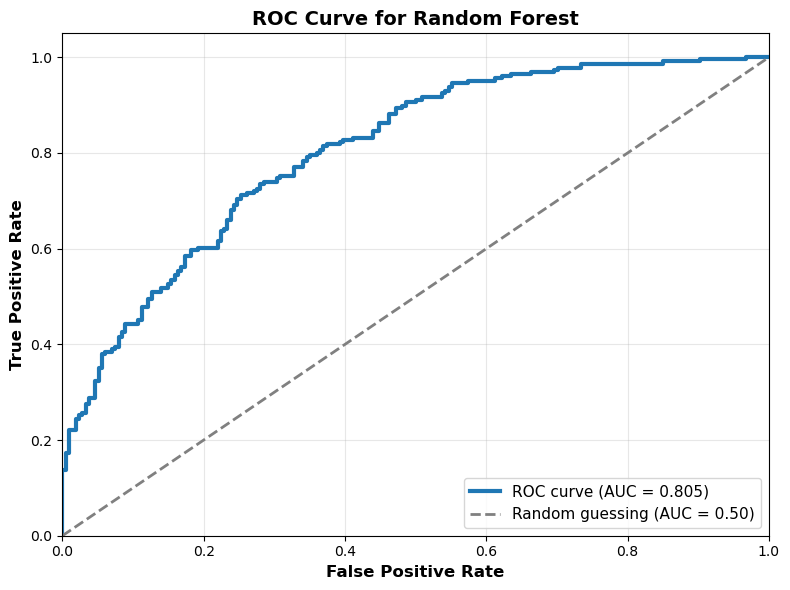

ROC AUC = 0.8045


In [92]:
# Plot ROC curve for the Random Forest model
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#1f77b4', linewidth=3, label=f'ROC curve (AUC = {roc_auc_value:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=2, label='Random guessing (AUC = 0.50)')

plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve for Random Forest', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

print(f'ROC AUC = {roc_auc_value:.4f}')

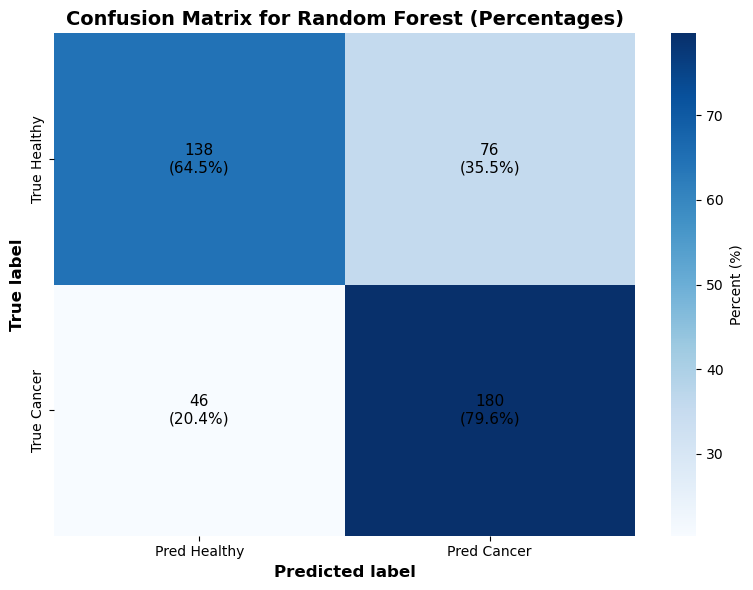

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predicted labels for the test set (use the fitted model)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

labels = ['Healthy', 'Cancer']

plt.figure(figsize=(8, 6))
sns.heatmap(cm_pct, annot=False, cmap='Blues', cbar=True,
            xticklabels=[f'Pred {l}' for l in labels],
            yticklabels=[f'True {l}' for l in labels],
            cbar_kws={'label': 'Percent (%)'})

# Add count + percentage annotations
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j + 0.5, i + 0.5,
                 f'{cm[i, j]}\n({cm_pct[i, j]:.1f}%)',
                 ha='center', va='center', color='black', fontsize=11)

plt.xlabel('Predicted label', fontsize=12, fontweight='bold')
plt.ylabel('True label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix for Random Forest (Percentages)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

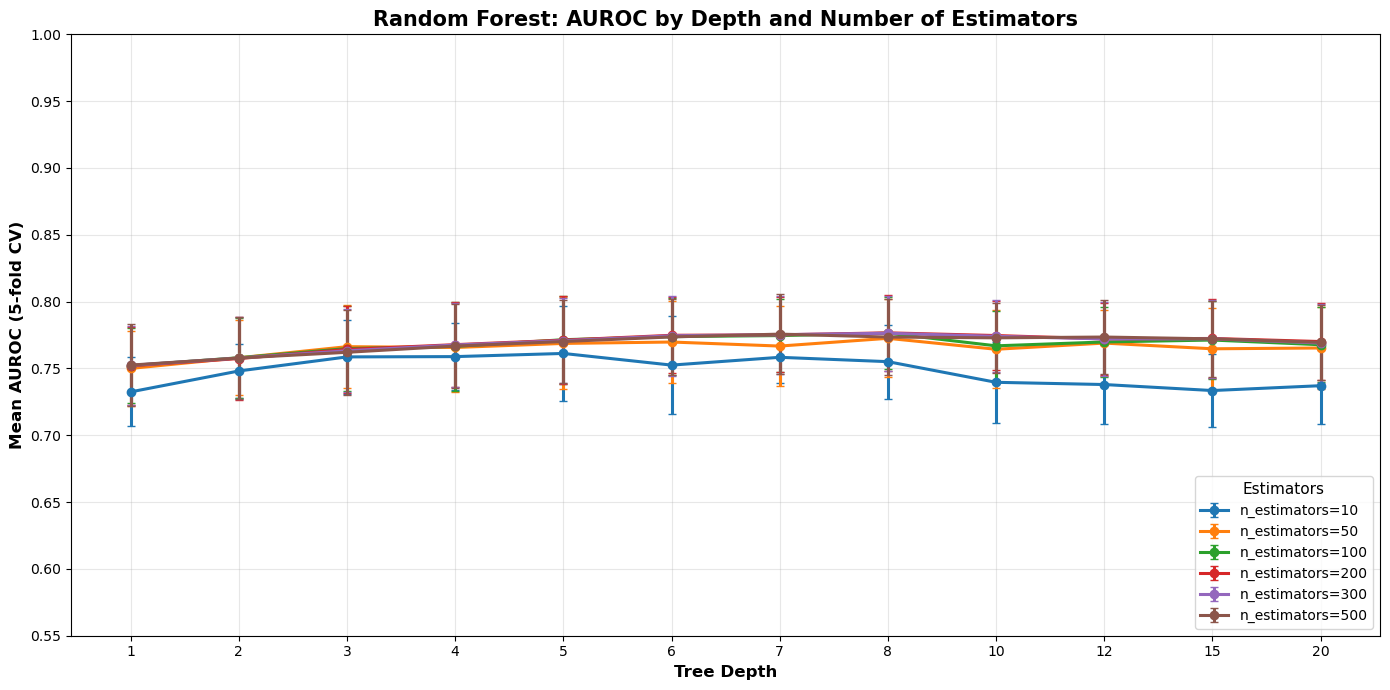

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

depths = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20]
estimators = [10, 50, 100, 200, 300, 500]

mean_auc = {n: [] for n in estimators}
std_auc = {n: [] for n in estimators}

for n in estimators:
    for depth in depths:
        rf = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            random_state=42,
            class_weight='balanced'
        )
        scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
        mean_auc[n].append(scores.mean())
        std_auc[n].append(scores.std())

x_positions = list(range(len(depths)))
labels = [str(d) for d in depths]

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, n in enumerate(estimators):
    ax.errorbar(
        x_positions,
        mean_auc[n],
        yerr=std_auc[n],
        fmt='-o',
        capsize=3,
        linewidth=2.2,
        markersize=6,
        color=colors[i],
        label=f'n_estimators={n}'
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(labels)
ax.set_xlabel('Tree Depth', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean AUROC (5-fold CV)', fontsize=12, fontweight='bold')
ax.set_title('Random Forest: AUROC by Depth and Number of Estimators', fontsize=15, fontweight='bold')
ax.legend(title='Estimators', fontsize=10, title_fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim([0.55, 1])

plt.tight_layout()
plt.show()
